# Stabilizzazione Video tramite Optical Flow (Lucas-Kanade)
Si occupa della **stabilizzazione di video tremolanti**. L'approccio si basa sull'individuazione di punti salienti e sul loro tracciamento nel tempo per stimare la traiettoria della videocamera e compensarne i movimenti indesiderati.

I passaggi fondamentali sono:
1. Individuazione di punti d'interesse (Shi-Tomasi) nel primo frame e tracciamento nel tempo tramite **Optical Flow di Lucas-Kanade**.
2. Calcolo della trasformazione affine (traslazione e rotazione) tra i frame consecutivi, per ricostruire la traiettoria globale (assoluta) del video originale.
3. Smoothing della traiettoria calcolata applicando un filtro a Media Mobile, eliminando il tremolio per ricavare il movimento "fluido".
4. Applicazione delle trasformazioni correttive ai frame originali e piccolo zoom (+4%) per nascondere i bordi neri. Output finale dei video affiancati.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

## Funzioni Ausiliarie
- `movingAverage` e `smooth`: Applicano un filtro a media mobile (Moving Average) per eliminare i picchi ad alta frequenza dalla traiettoria globale calcolata (il tremolio).
- `fixBorder`: Applica una zoom del +4% attorno al centro per evitare la visualizzazione di "bordi neri" quando l'immagine stabilizzata viene traslata o ruotata.

In [2]:
def movingAverage (curve, radius) :
    window_size = 2 * radius + 1 
    f = np.ones(window_size) / window_size # Filtro
    curve_pad = np.pad(curve, (radius, radius), 'edge') # Padding
    curve_smoothed = np.convolve(curve_pad, f, mode='same') # Convoluzione
    return curve_smoothed[radius:-radius] # Qui il padding viene rimosso

def smooth (trajectory) :
    smoothed_trajectory = np.copy(trajectory)
    for i in range (3) : # Filtra x, y e angolo
        smoothed_trajectory[:, i] = movingAverage(trajectory[:, i], radius=30)
    return smoothed_trajectory

def fixBorder (frame) :
    s = frame.shape
    # Zoomma 4%
    T = cv2.getRotationMatrix2D((s[1]/2, s[0]/2), 0, 1.04)
    return cv2.warpAffine(frame, T, (s[1], s[0]))

In [3]:
data_dir = "data"
folders = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')])
print(f"Cartelle trovate: {folders}")


Cartelle trovate: ['climbing1', 'climbing2', 'driving1', 'driving2', 'riding1', 'riding2', 'walking1', 'walking2']


## Parametri dell'Algoritmo
- **lk_params**: Parametri per l'algoritmo Lucas-Kanade.
- **feature_params**: Parametri per la ricerca dei "punti buoni da tracciare" tramite l'algoritmo Shi-Tomasi (`cv2.goodFeaturesToTrack`).
- **REDETECT_INTERVAL**: Forza la ricerca di nuovi punti ogni 30 frame, essenziale per evitare il "drift" (perdita progressiva di tracking e accumulo d'errore).

In [4]:
lk_params = dict (
    winSize=(21,21),
    maxLevel=3,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
)

feature_params = dict (
    maxCorners=500,
    qualityLevel=0.01,
    minDistance=30,
    blockSize=3
)

# soglia minima di punti prima di rilevarne di nuovi
MIN_POINTS = 50

# ogni quanti frame forzare il rilevamento
REDETECT_INTERVAL = 30


## Elaborazione e Stabilizzazione 
In questo blocco avviene tutta l'elaborazione.
Per ogni video tremolante (`shaky.mp4`):
1. Tracciamento dei punti tramite l'Optical Flow e calcolo delle differenze frame-by-frame. Viene accumulato il movimento per creare la `trajectory` originale.
2. Generazione della `smoothed_trajectory` e calcolo della correzione (`transforms_smooth`). Visualizzazione del grafico della traiettoria.
3. Rilettura dei frame e correzione tramite `cv2.warpAffine`. I video finali stabilizzati vengono generati e salvati affiancati (`hconcat`).


Elaborazione: climbing1
Frame letti: 498


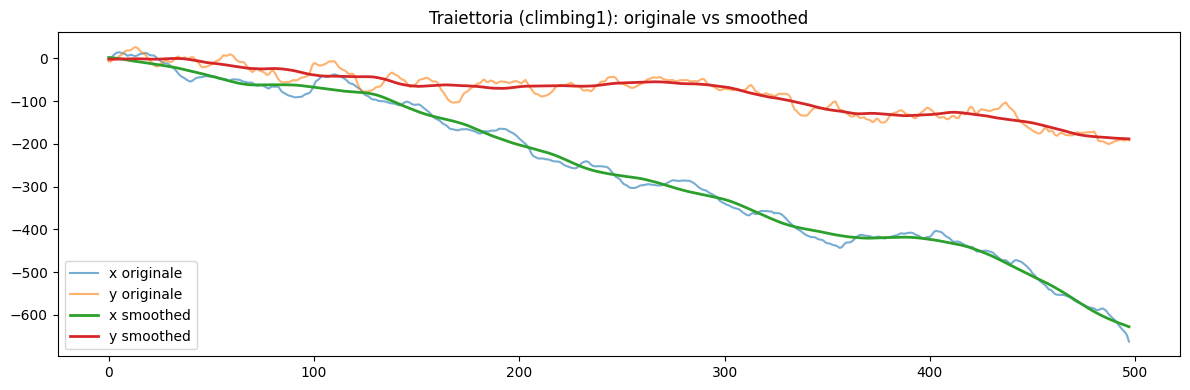

Video stabilizzati salvati in: data/climbing1/Lucas-Kanade Optical Flow

Elaborazione: climbing2
Frame letti: 498


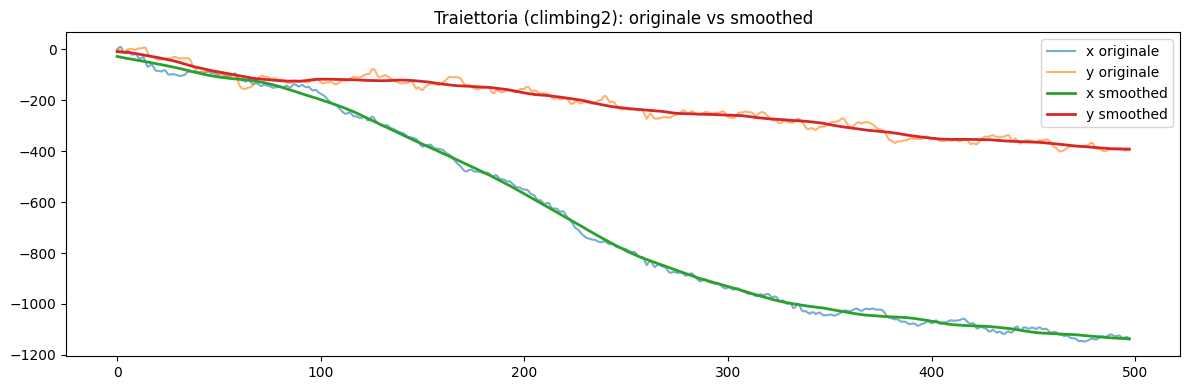

Video stabilizzati salvati in: data/climbing2/Lucas-Kanade Optical Flow

Elaborazione: driving1
Frame letti: 498


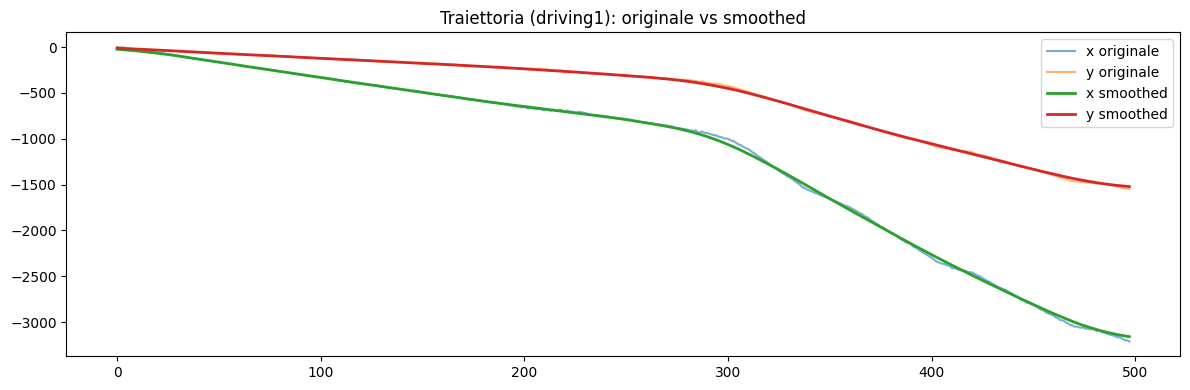

Video stabilizzati salvati in: data/driving1/Lucas-Kanade Optical Flow

Elaborazione: driving2
Frame letti: 498


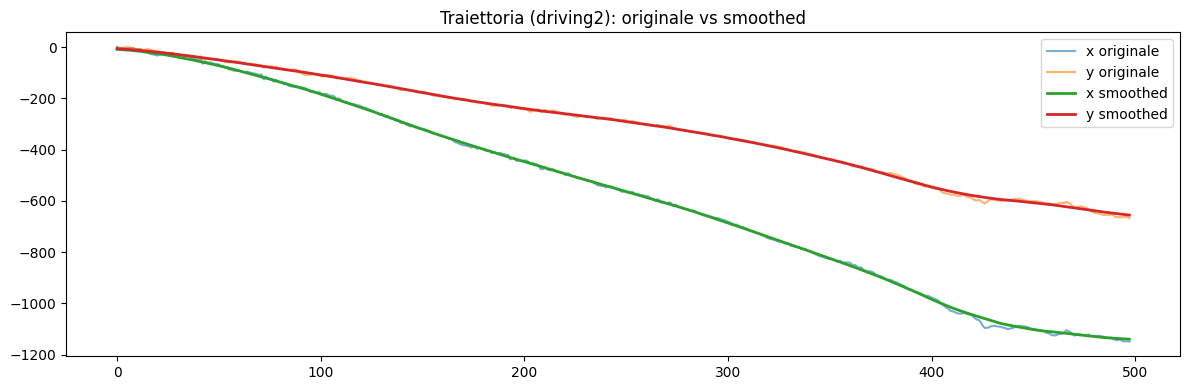

Video stabilizzati salvati in: data/driving2/Lucas-Kanade Optical Flow

Elaborazione: riding1
Frame letti: 498


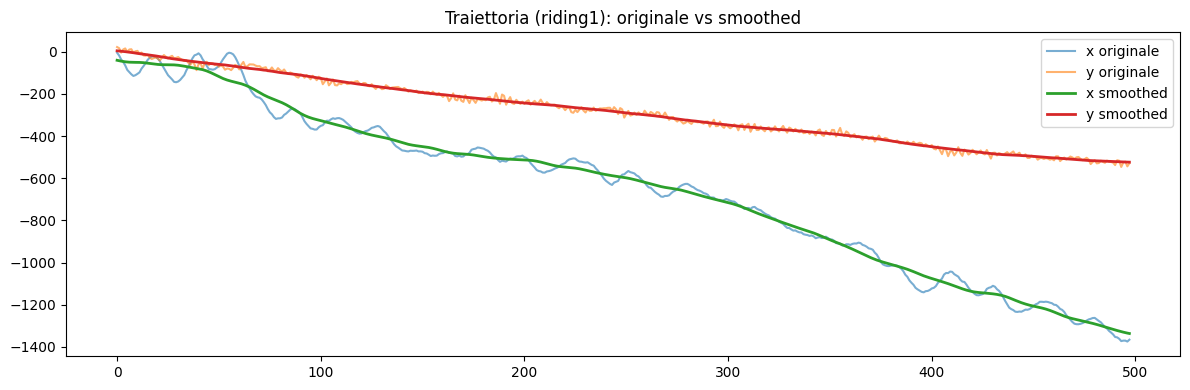

Video stabilizzati salvati in: data/riding1/Lucas-Kanade Optical Flow

Elaborazione: riding2
Frame letti: 498


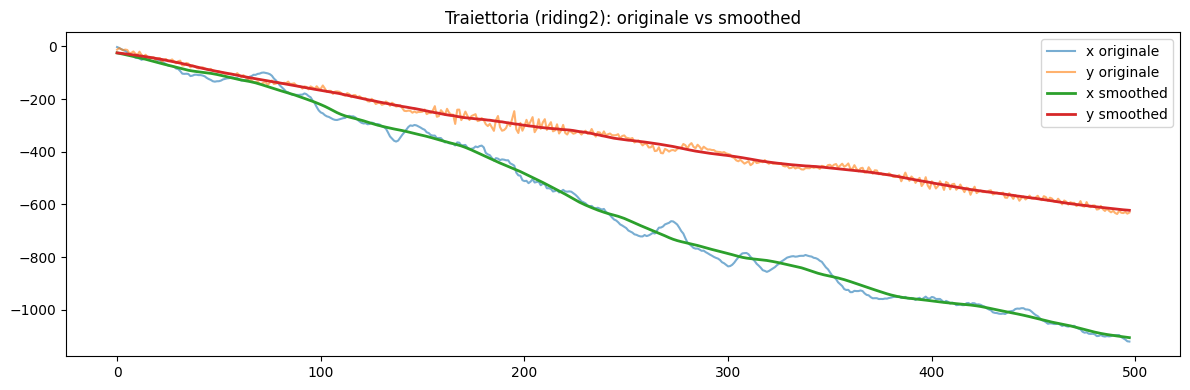

Video stabilizzati salvati in: data/riding2/Lucas-Kanade Optical Flow

Elaborazione: walking1
Frame letti: 698


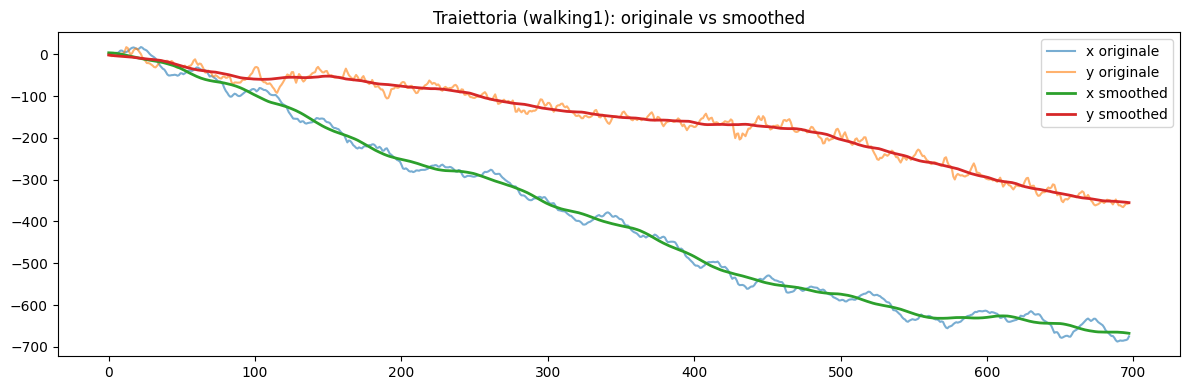

Video stabilizzati salvati in: data/walking1/Lucas-Kanade Optical Flow

Elaborazione: walking2
Frame letti: 248


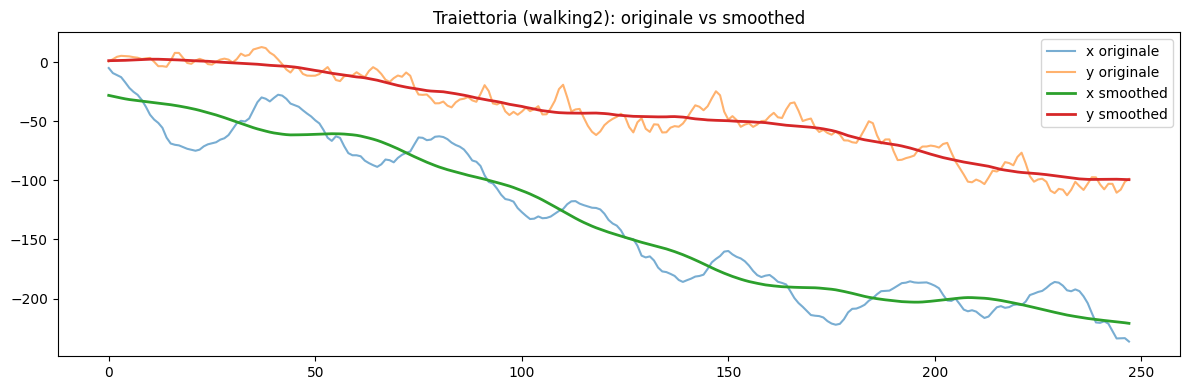

Video stabilizzati salvati in: data/walking2/Lucas-Kanade Optical Flow

Elaborazione completata!


In [5]:
for folder in folders:
    print(f"\n{'='*60}")
    print(f"Elaborazione: {folder}")
    print(f"{'='*60}")
    
    path = os.path.join(data_dir, folder)
    
    if not os.path.exists(os.path.join(path, "shaky.mp4")):
        print(f"SKIP: shaky.mp4 non trovato in {folder}")
        continue
    
    output_folder = os.path.join(path, "Lucas-Kanade Optical Flow")
    os.makedirs(output_folder, exist_ok=True)
    
    cap = cv2.VideoCapture(os.path.join(path, "shaky.mp4"))
    cap_groundtruth = cv2.VideoCapture(os.path.join(path, "groundtruth.mp4"))

    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_mask = cv2.VideoWriter(os.path.join(output_folder, "mask.mp4"), fourcc, fps, (w, h))

    success, prev = cap.read()
    if not success:
        print(f"ERRORE: Impossibile leggere il primo frame di {folder}")
        cap.release()
        continue

    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
    mask = np.zeros_like(prev)

    prev_pts = cv2.goodFeaturesToTrack(prev_gray, **feature_params)

    transforms = np.zeros((n_frames-1, 3), np.float32)
    frames_read = 0

    for frame_idx in range(n_frames-1):
        success, curr = cap.read()
        if not success:
            break

        frames_read += 1
        curr_gray = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)

        # Ri-rileva punti se sono troppo pochi oppure ogni REDETECT_INTERVAL frame
        if prev_pts is None or len(prev_pts) < MIN_POINTS or frame_idx % REDETECT_INTERVAL == 0:
            prev_pts = cv2.goodFeaturesToTrack(prev_gray, **feature_params)

        # Calcolo optical flow Lucas-Kanade
        curr_pts, status, err = cv2.calcOpticalFlowPyrLK(
            prev_gray, curr_gray, prev_pts, None, **lk_params
        )

        # Caso in cui il tracking fallisce completamente
        if curr_pts is None or status is None:
            transforms[frame_idx] = [0, 0, 0]
            prev_gray = curr_gray.copy()
            prev_pts = cv2.goodFeaturesToTrack(prev_gray, **feature_params)
            continue

        # Filtra solo i punti validi
        idx = np.where(status == 1)[0]
        good_old = prev_pts[idx]
        good_new = curr_pts[idx]

        # Check che ci siano abbastanza punti per poter stimare la trasformazione
        if len(good_old) < 4:
            transforms[frame_idx] = [0, 0, 0]
            prev_gray = curr_gray.copy()
            prev_pts = cv2.goodFeaturesToTrack(prev_gray, **feature_params)
            continue

        # Stima trasformazione affine
        m, _ = cv2.estimateAffine2D(good_old, good_new)

        # Controlla che la stima sia andata a buon fine
        if m is None:
            transforms[frame_idx] = [0, 0, 0]
            prev_gray = curr_gray.copy()
            prev_pts = cv2.goodFeaturesToTrack(prev_gray, **feature_params)
            continue

        # Estrai traslazioni
        dx = m[0, 2]
        dy = m[1, 2]

        # Estrai angolo di rotazione
        da = np.arctan2(m[1, 0], m[0, 0])

        transforms[frame_idx] = [dx, dy, da]

        # Disegna optical flow sulla maschera
        for j, (new, old) in enumerate(zip(good_new, good_old)):
            a, b = new.ravel()
            c, d = old.ravel()
            mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), (0, 0, 255), 1)
            curr = cv2.circle(curr, (int(a), int(b)), 5, (0, 0, 255), -1)

        img = cv2.add(curr, mask)

        # Aggiorna frame e punti precedenti
        prev_gray = curr_gray.copy()
        prev_pts = good_new.reshape(-1, 1, 2)  # usa i punti tracked come nuovi prev

        out_mask.write(img)

    cap.release()
    out_mask.release()

    # Tronca transforms ai frame effettivamente letti
    transforms = transforms[:frames_read]

    print(f"Frame letti: {frames_read}")

    trajectory = np.cumsum(transforms, axis=0)
    smoothed_trajectory = smooth(trajectory)
    difference = smoothed_trajectory - trajectory
    transforms_smooth = transforms + difference

    # Plot traiettoria originale vs smoothed
    time = np.arange(len(trajectory))
    plt.figure(figsize=(12, 4))
    plt.plot(time, trajectory[:, 0], label='x originale', alpha=0.6)
    plt.plot(time, trajectory[:, 1], label='y originale', alpha=0.6)
    plt.plot(time, smoothed_trajectory[:, 0], label='x smoothed', linewidth=2)
    plt.plot(time, smoothed_trajectory[:, 1], label='y smoothed', linewidth=2)
    plt.legend()
    plt.title(f"Traiettoria ({folder}): originale vs smoothed")
    plt.tight_layout()
    plt.show()

    cap = cv2.VideoCapture(os.path.join(path, "shaky.mp4"))
    cap_groundtruth = cv2.VideoCapture(os.path.join(path, "groundtruth.mp4"))

    out_shaky = cv2.VideoWriter(os.path.join(output_folder, "comparison_shaky.mp4"), fourcc, fps, (2 * w, h))
    out_groundtruth = cv2.VideoWriter(os.path.join(output_folder, "comparison_groundtruth.mp4"), fourcc, fps, (2 * w, h))

    for i in range(frames_read):
        success, frame = cap.read()
        if not success:
            break

        success, frame_gt = cap_groundtruth.read()
        if not success:
            break

        dx = transforms_smooth[i, 0]
        dy = transforms_smooth[i, 1]
        da = transforms_smooth[i, 2]

        # Ricostruisce matrice di trasformazione affine
        m = np.array([
            [np.cos(da), -np.sin(da), dx],
            [np.sin(da),  np.cos(da), dy]
        ], dtype=np.float32)

        frame_stabilized = cv2.warpAffine(frame, m, (w, h))
        frame_stabilized = fixBorder(frame_stabilized)

        frame_shaky_out = cv2.hconcat([frame, frame_stabilized])
        frame_gt_out    = cv2.hconcat([frame_gt, frame_stabilized])

        out_shaky.write(frame_shaky_out)
        out_groundtruth.write(frame_gt_out)

        cv2.waitKey(10)

    cap.release()
    cap_groundtruth.release()
    out_shaky.release()
    out_groundtruth.release()

    print(f"Video stabilizzati salvati in: {output_folder}")

cv2.destroyAllWindows()
print(f"\n{'='*60}")
print("Elaborazione completata!")
print(f"{'='*60}")
